Original shape: (42016, 52)
Reduced shape after PCA: (42016, 11)


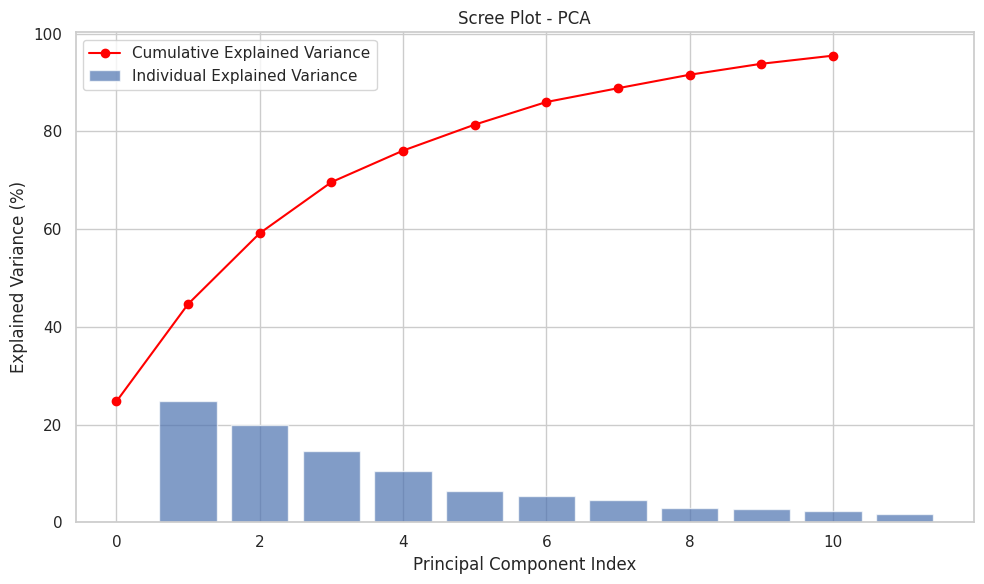

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
data = pd.read_csv("/content/DMC2_S_CP2_52.csv")

# 2. Extract the target column before dropping it
y = data['CURRENT|1']

X = data.iloc[:, :-4]

# 3. Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Apply PCA (retain 95% variance)
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

# 5. Display shapes
print(f"Original shape: {X.shape}")
print(f"Reduced shape after PCA: {X_pca.shape}")

# 6. Create DataFrame with principal components
pca_df = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(X_pca.shape[1])])
pca_df['CURRENT|1'] = y.values  # Add target column back

# 7. Save reduced dataset
pca_df.to_csv("pca_data.csv", index=False)

# 8. Plot Scree Plot (individual + cumulative variance)
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

# Bar plot for individual variance
plt.bar(range(1, len(pca.explained_variance_ratio_)+1),
        pca.explained_variance_ratio_*100, alpha=0.7, label='Individual Explained Variance')

# Line plot for cumulative variance
plt.plot(np.cumsum(pca.explained_variance_ratio_)*100,
         color='red', marker='o', label='Cumulative Explained Variance')

plt.xlabel("Principal Component Index")
plt.ylabel("Explained Variance (%)")
plt.title("Scree Plot - PCA")
plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [ ]:
pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,CURRENT|1
0,9.280211,-1.423706,1.970918,2.432996,-0.332150,-1.194646,0.705661,-0.719141,-0.189582,0.054184,0.235312,-0.273438
1,9.280008,-1.424751,1.969029,2.433316,-0.331677,-1.194442,0.705670,-0.723126,-0.190830,0.058199,0.235567,-0.273438
2,9.279963,-1.425712,1.969636,2.433056,-0.331909,-1.193693,0.706448,-0.724401,-0.190480,0.058455,0.235828,-0.273438
3,9.280345,-1.424548,1.969022,2.432979,-0.331946,-1.193731,0.706796,-0.720871,-0.190329,0.057981,0.235773,-0.273438
4,9.280459,-1.424924,1.968945,2.430834,-0.331751,-1.194695,0.705038,-0.718663,-0.193937,0.057010,0.237353,-0.273438


## LOADING PLOT

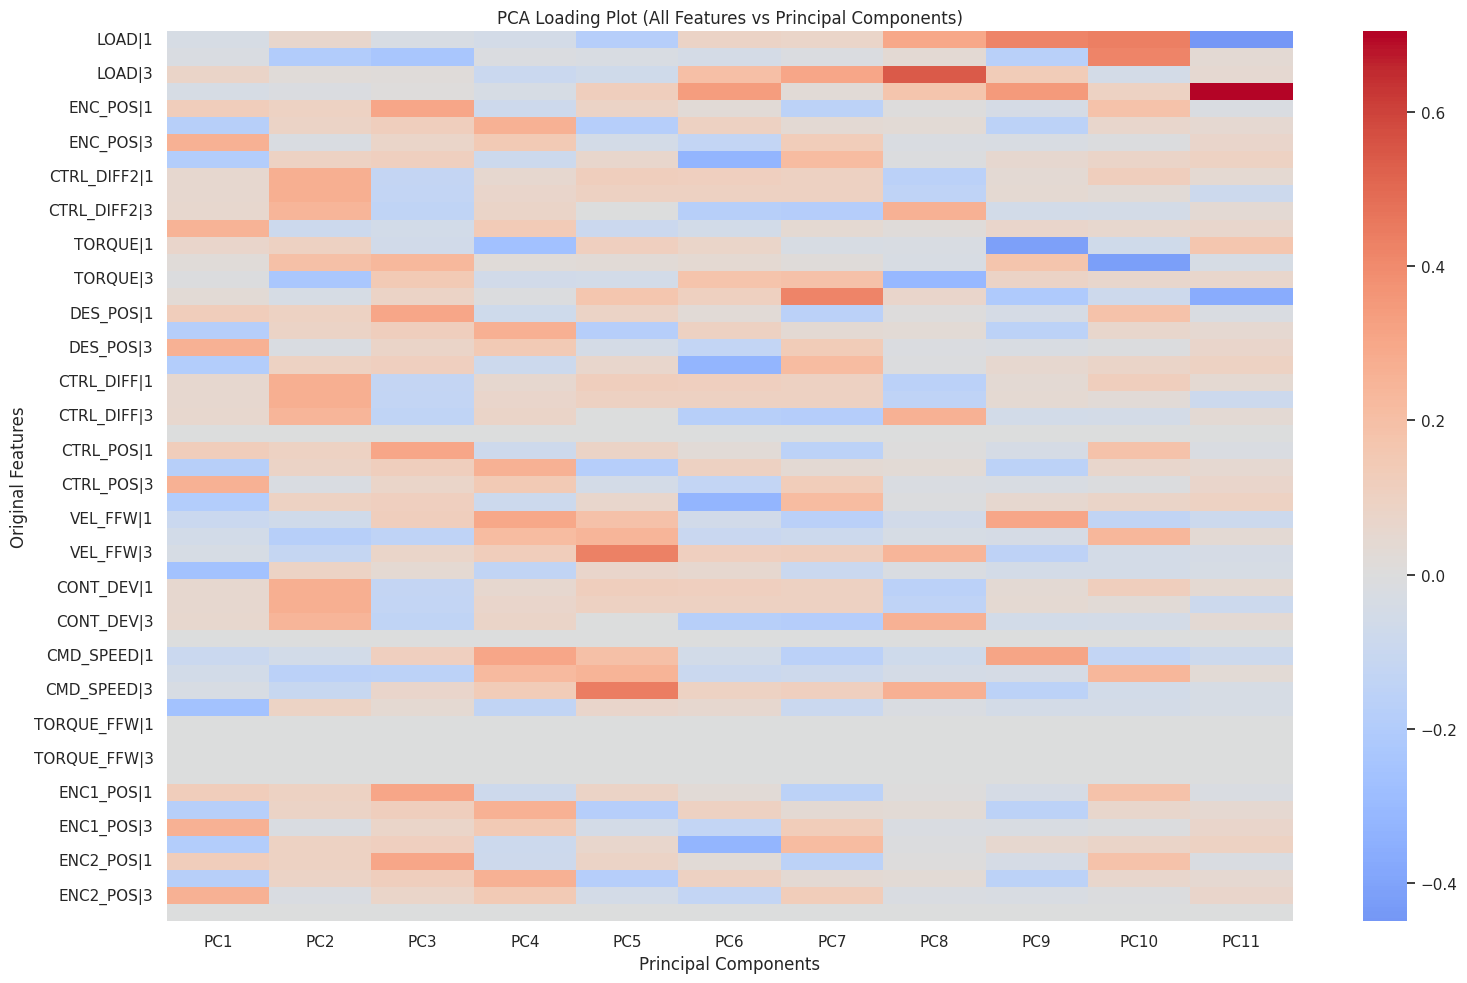

In [ ]:



# Create loading matrix
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=X.columns
)

# Plot loading heatmap for all features
plt.figure(figsize=(16, 10))
sns.heatmap(loadings, cmap="coolwarm", center=0)
plt.title("PCA Loading Plot (All Features vs Principal Components)")
plt.xlabel("Principal Components")
plt.ylabel("Original Features")
plt.tight_layout()
plt.show()

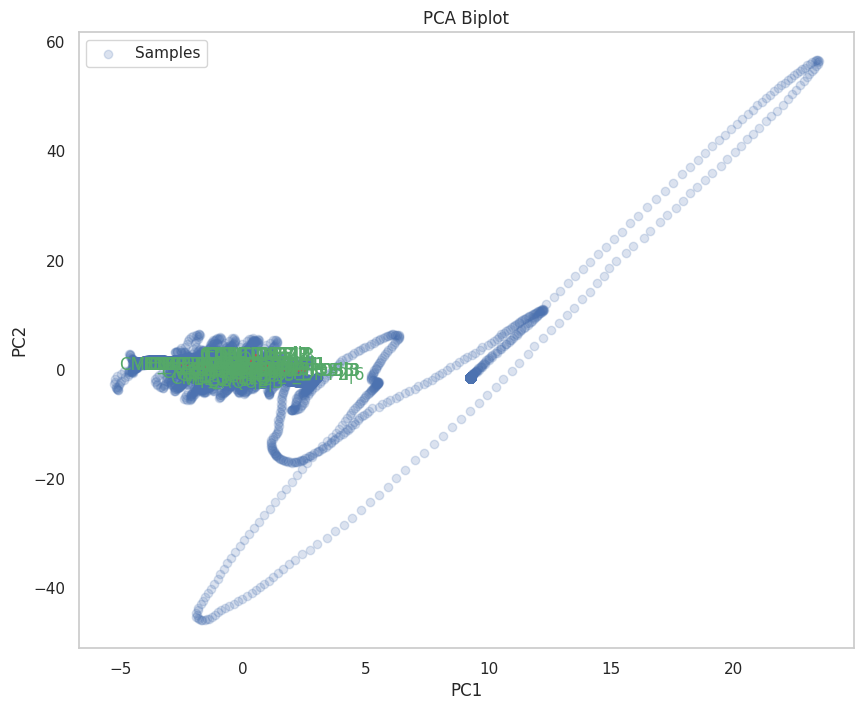

In [ ]:
import matplotlib.pyplot as plt

# Loadings
loadings = pca.components_.T
feature_names = data.columns[:52]

plt.figure(figsize=(10, 8))
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.2, label='Samples')
for i, feature in enumerate(feature_names):
    plt.arrow(0, 0, loadings[i, 0]*10, loadings[i, 1]*10, color='r', alpha=0.5)
    plt.text(loadings[i, 0]*10.2, loadings[i, 1]*10.2, feature, color='g', ha='center', va='center')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Biplot')
plt.grid()
plt.legend()
plt.show()

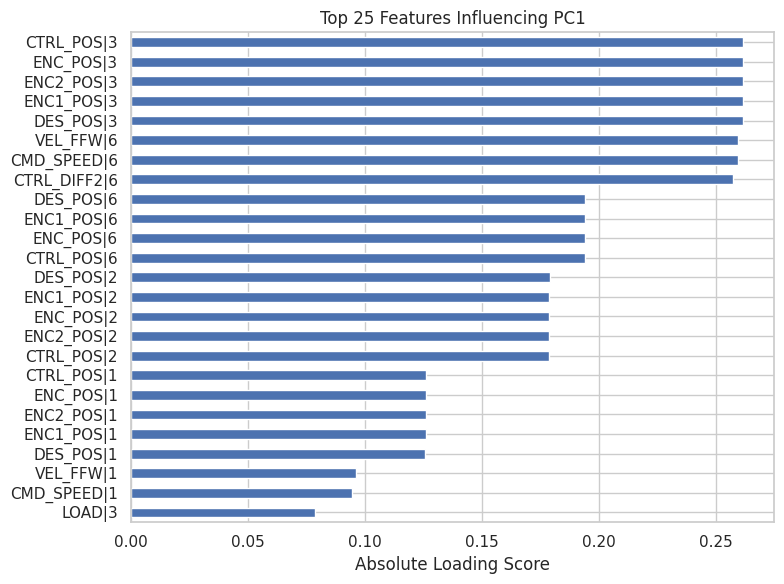

In [ ]:
import numpy as np

# Top features for PC1
pc_index = 0  # 0 for PC1, 1 for PC2, etc.
top_n = 25
loading_scores = pd.Series(np.abs(loadings[:, pc_index]), index=feature_names)
top_features = loading_scores.nlargest(top_n)

top_features.plot(kind='barh', figsize=(8, 6), title=f"Top {top_n} Features Influencing PC{pc_index + 1}")
plt.xlabel("Absolute Loading Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

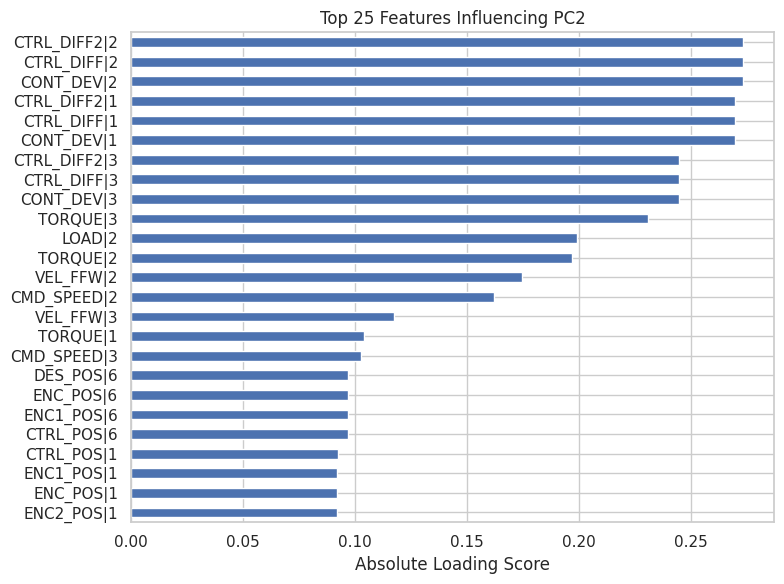

In [ ]:
import numpy as np

# Top features for PC1
pc_index = 1  # 0 for PC1, 1 for PC2, etc.
top_n = 25
loading_scores = pd.Series(np.abs(loadings[:, pc_index]), index=feature_names)
top_features = loading_scores.nlargest(top_n)

top_features.plot(kind='barh', figsize=(8, 6), title=f"Top {top_n} Features Influencing PC{pc_index + 1}")
plt.xlabel("Absolute Loading Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

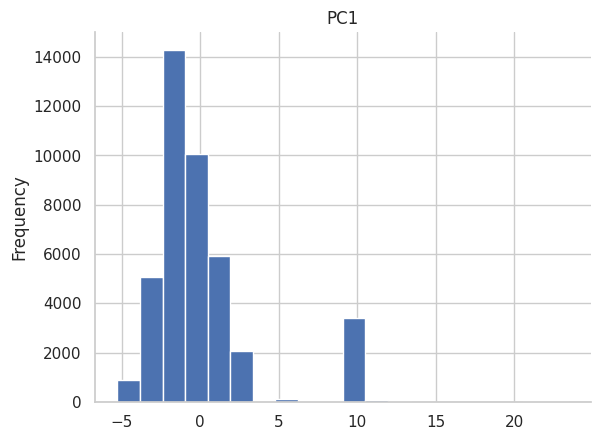

In [ ]:
# @title PC1

from matplotlib import pyplot as plt
pca_df['PC1'].plot(kind='hist', bins=20, title='PC1')
plt.gca().spines[['top', 'right',]].set_visible(False)

Dataset info

In [ ]:
data = pd.read_csv("/content/DMC2_S_CP2_52.csv")

data.info()

pca_df = pd.read_csv("pca_data.csv")
pca_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42016 entries, 0 to 42015
Data columns (total 56 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   LOAD|1        42016 non-null  float64
 1   LOAD|2        42016 non-null  float64
 2   LOAD|3        42016 non-null  float64
 3   LOAD|6        42016 non-null  float64
 4   ENC_POS|1     42016 non-null  float64
 5   ENC_POS|2     42016 non-null  float64
 6   ENC_POS|3     42016 non-null  float64
 7   ENC_POS|6     42016 non-null  float64
 8   CTRL_DIFF2|1  42016 non-null  float64
 9   CTRL_DIFF2|2  42016 non-null  float64
 10  CTRL_DIFF2|3  42016 non-null  float64
 11  CTRL_DIFF2|6  42016 non-null  float64
 12  TORQUE|1      42016 non-null  float64
 13  TORQUE|2      42016 non-null  float64
 14  TORQUE|3      42016 non-null  float64
 15  TORQUE|6      42016 non-null  float64
 16  DES_POS|1     42016 non-null  float64
 17  DES_POS|2     42016 non-null  float64
 18  DES_POS|3     42016 non-nu

## Predict target in PCA Dataset using LSTM

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt

# --- 1. Load PCA-reduced dataset ---
pca_df = pd.read_csv("pca_data.csv")

# --- 2. Split features & target ---
X = pca_df.drop(columns=['CURRENT|1']).values
y = pca_df['CURRENT|1'].values.reshape(-1, 1)

# --- 3. Scale both X and y ---
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_x.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# --- 4. Create sequences ---
def create_sequences(X, y, window_size=10):
    X_seq, y_seq = [], []
    for i in range(len(X) - window_size):
        X_seq.append(X[i:i+window_size])
        y_seq.append(y[i+window_size])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, window_size=10)

# --- 5. Train-test split ---
split = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

# Check shape of training and testing data
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (33604, 10, 11)
X_test shape: (8402, 10, 11)
y_train shape: (33604, 1)
y_test shape: (8402, 1)


In [ ]:
model = Sequential([
    LSTM(64, input_shape=(window_size, 11)),   # 11 PCA features
    Dense(32, activation='relu'),
    Dense(1)  # Final output
])
model.compile(optimizer='adam', loss='mse')
model.summary()

# --- 7. Train the model ---
history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=20, batch_size=64, verbose=1)

# --- 8. Predict ---
y_pred = model.predict(X_test)

# --- 9. Inverse transform predictions ---
y_pred_inv = scaler_y.inverse_transform(y_pred)
y_test_inv = scaler_y.inverse_transform(y_test)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 64)             │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,569 (84.25 KB)

 Trainable params: 21,569 (84.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.0073 - val_loss: 0.0017
Epoch 2/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 8.3611e-04 - val_loss: 0.0023
Epoch 3/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 6.6991e-04 - val_loss: 0.0020
Epoch 4/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 5.8620e-04 - val_loss: 0.0018
Epoch 5/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 4.5838e-04 - val_loss: 0.0013
Epoch 6/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 4.1139e-04 - val_loss: 0.0023
Epoch 7/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 3.3513e-04 - val_loss: 0.0021
Epoch 8/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 2.9293e-04 - val_loss: 0.0015
Epoch 9/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 2.2728e-04 - val_loss: 7.3874e-04
Epoch 10/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 2.1972e-04 - val_loss: 0.0013
Epoch 11/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 1.8447e-04 - val_loss: 0.0016
Ep

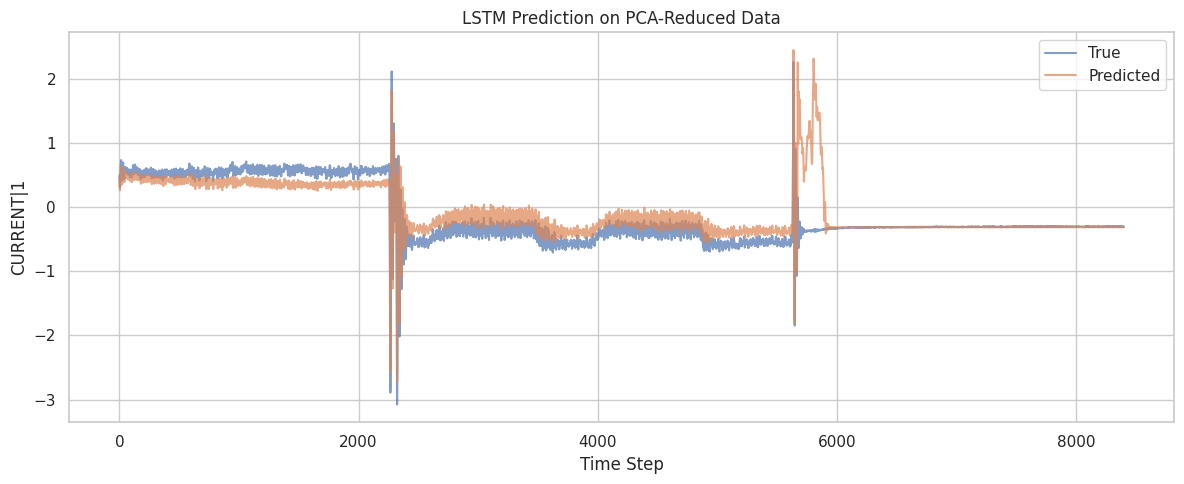

In [ ]:

# --- 11. Plot Predictions vs Actual ---
plt.figure(figsize=(12, 5))
plt.plot(y_test_inv, label='True', alpha=0.7)
plt.plot(y_pred_inv, label='Predicted', alpha=0.7)
plt.title("LSTM Prediction on PCA-Reduced Data")
plt.xlabel("Time Step")
plt.ylabel("CURRENT|1")
plt.legend()
plt.tight_layout()
plt.show()

###evaluate

In [ ]:
# --- 10. Evaluation ---
mae = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
r2 = r2_score(y_test_inv, y_pred_inv)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")


MAE: 0.1631
RMSE: 0.3023
R2 Score: 0.5648


In [ ]:
# New result as a dictionary
new_result = {
    "model": "LSTM-pca",
    "epochs": 20,
    "features": 11,
    "window_size": 10,
    "MAE": 0.1631,
    "RMSE": 0.3023,
    "R2": 0.5648
}

# Convert to DataFrame and concatenate
new_row_df = pd.DataFrame([new_result])
results_df = pd.concat([results_df, new_row_df], ignore_index=True)

In [ ]:
results_df.to_csv("model_results.csv", index=False)

## Predict target in OG Dataset using LSTM

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv("/content/DMC2_S_CP2_52.csv")  # replace with your filename

# Separate features and target
feature_cols = df.columns[:52]  # First 52 columns are features
target_col = 'CURRENT|1'

X = df[feature_cols]
y = df[[target_col]]

# Normalize
scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y)

# Create sequences
def create_sequences(X, y, time_steps=10):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:i+time_steps])
        ys.append(y[i+time_steps])
    return np.array(Xs), np.array(ys)

time_steps = 10
X_seq, y_seq = create_sequences(X_scaled, y_scaled, time_steps)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42)
# Check shape of training and testing data
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)




X_train shape: (33604, 10, 52)
X_test shape: (8402, 10, 52)
y_train shape: (33604, 1)
y_test shape: (8402, 1)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 64)             │        29,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,065 (125.25 KB)

 Trainable params: 32,065 (125.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 52s 10ms/step - loss: 0.0130 - val_loss: 9.5084e-04
Epoch 2/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 5.9957e-04 - val_loss: 4.3224e-04
Epoch 3/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 3.6614e-04 - val_loss: 2.4684e-04
Epoch 4/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 2.4555e-04 - val_loss: 2.0881e-04
Epoch 5/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 1.6441e-04 - val_loss: 1.4142e-04
Epoch 6/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 9.0118e-05 - val_loss: 9.4388e-05
Epoch 7/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 7.8347e-05 - val_loss: 5.7209e-05
Epoch 8/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 6.1279e-05 - val_loss: 3.0053e-04
Epoch 9/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 5.8645e-05 - val_loss: 1.8503e-04
Epoch 10/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 6.9207e-05 - val_loss: 3.2241e-04
Epoch 11/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms

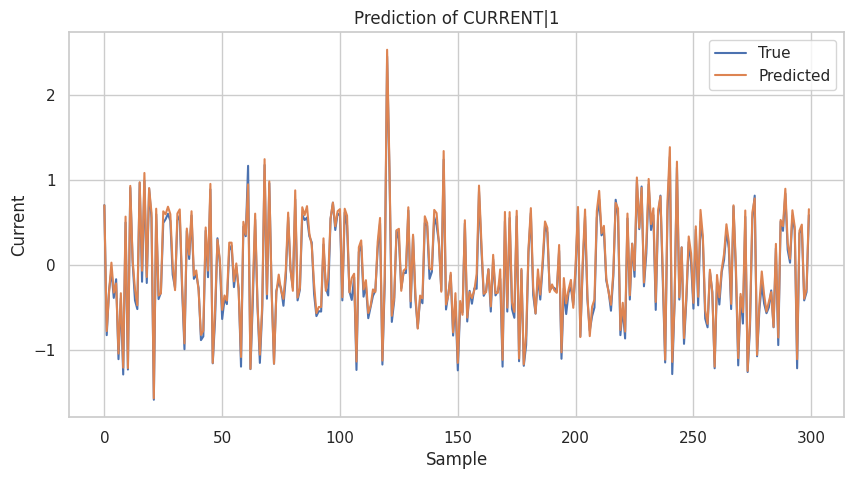

In [ ]:
# Build LSTM model
model = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# Train
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=20, batch_size=64)

# Predict and inverse transform
y_pred = model.predict(X_test)
y_pred_inv = scaler_y.inverse_transform(y_pred)
y_test_inv = scaler_y.inverse_transform(y_test)

# Plot results
plt.figure(figsize=(10, 5))
plt.plot(y_test_inv[:300], label='True')
plt.plot(y_pred_inv[:300], label='Predicted')
plt.title('Prediction of CURRENT|1')
plt.xlabel('Sample')
plt.ylabel('Current')
plt.legend()
plt.show()

# Evaluation

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Assuming: y_test and y_pred are your true and predicted values
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

MAE: 0.0063
RMSE: 0.0075
R2 Score: 0.9894


## SAve REult to new DF

In [ ]:
import pandas as pd

# Try loading existing results if file exists
try:
    results_df = pd.read_csv("model_results.csv")
except FileNotFoundError:
    results_df = pd.DataFrame(columns=["model", "epochs", "features", "window_size", "MAE", "RMSE", "R2"])


In [ ]:


# New result as a dictionary
new_result = {
    "model": "LSTM-Og",
    "epochs": 20,
    "features": 52,
    "window_size": 10,
    "MAE": 0.0063,
    "RMSE": 0.0075,
    "R2": 0.9894
}

# Convert to DataFrame and concatenate
new_row_df = pd.DataFrame([new_result])
results_df = pd.concat([results_df, new_row_df], ignore_index=True)

# Save to CSV
results_df.to_csv("model_results.csv", index=False)